# Dense Optical Flow: Detecting Motion in Videos

## What You'll Learn:
1. **What is Optical Flow** - The concept of motion detection
2. **Dense Optical Flow** - Calculating motion for every pixel
3. **Farneback Algorithm** - A popular method for dense optical flow
4. **Activity Recognition** - Identifying walking, running, and waving from motion
5. **Practical Implementation** - Real code examples with visualization

---

## Important Concept: What is Optical Flow?

**Optical Flow** is the pattern of apparent motion of objects, surfaces, and edges in a visual sequence caused by the relative motion between an observer (camera) and a scene.

### Simple Analogy:
Imagine you're looking out a moving car window. Trees and buildings appear to move backward - that's optical flow! The pattern of this motion tells us how fast we're moving and in what direction.

In videos, optical flow helps us:
- Detect movement
- Track objects
- Recognize activities (walking, running, etc.)
- Estimate camera motion
- Compress videos

### Types of Optical Flow:

| Type | Description | Use Case |
|------|-------------|----------|
| **Sparse Optical Flow** | Calculate motion for specific feature points | Fast, fewer calculations, tracking |
| **Dense Optical Flow** | Calculate motion for **every pixel** | Detailed motion map, activity recognition |

We'll focus on **Dense Optical Flow** because it gives us a complete picture of motion in the frame.

---

## The Farneback Algorithm: A Beginner's Explanation

Gunnar Farnebäck developed an algorithm that calculates optical flow by:

1. **Breaking the image into small patches** - Instead of looking at the whole image, divide it into overlapping windows
2. **Fitting polynomial approximations** - Model how pixel intensities change within each patch
3. **Calculating motion** - Based on how the polynomial would need to shift to match the next frame

Think of it like this:
- You have a pattern in frame 1
- You look for a similar pattern in frame 2
- The shift between them = motion (optical flow)

The result is a **flow field**: for every pixel, we get a vector (vx, vy) showing:
- **vx** = horizontal motion (pixels per frame)
- **vy** = vertical motion (pixels per frame)

---

## Why Dense Optical Flow for Activity Recognition?

When someone **runs**, **walks**, or **waves**, the motion is different:
- **Walking** - Slow, consistent, upward/downward motion of legs
- **Running** - Fast, more dynamic motion throughout body
- **Waving** - Fast motion localized to arms/hands

By analyzing the **magnitude** (strength) of optical flow:
- Large magnitude = fast motion = running
- Medium magnitude = slow motion = walking  
- Localized magnitude = part of body moving = waving

This gives us a way to classify activities without deep learning!

## Part 1: Set Up Our Environment

Let's import all the libraries we need and understand what each one does.

In [4]:
import cv2                      # OpenCV - for image/video processing
import numpy as np              # NumPy - for numerical operations
import matplotlib.pyplot as plt  # Plotting - for visualization
from matplotlib import cm       # Color maps for nice visualizations
import os
from pathlib import Path

# Display settings
plt.style.use('seaborn-v0_8-darkgrid')
print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## Part 2: Understanding Dense Optical Flow (Mathematical Intuition)

### The Brightness Constancy Assumption

Dense optical flow is based on one main idea:
**"A pixel's brightness doesn't change as it moves between frames"**

In mathematical form:
```
I(x, y, t) = I(x + u·Δt, y + v·Δt, t + Δt)
```

Where:
- **I(x, y, t)** = brightness (intensity) at pixel (x,y) at time t
- **u** = horizontal velocity (pixels per frame)
- **v** = vertical velocity (pixels per frame)  
- **Δt** = time between frames (usually 1 frame)

### Optical Flow Equation (Simplified)

Using calculus (Taylor expansion), we get:
```
Ix·u + Iy·v + It = 0
```

Where:
- **Ix** = change in brightness across x-axis (horizontal gradient)
- **Iy** = change in brightness across y-axis (vertical gradient)
- **It** = change in brightness over time
- **u, v** = optical flow vectors we want to find

#### What This Means in Simple Terms:

If a pixel gets brighter from left to right (**Ix > 0**), and the brightness is increasing over time (**It > 0**), then the bright pixels must be moving from left to right (**u > 0**).

It's like tracking a moving shadow - the direction and speed of brightness change tells us direction and speed of motion!

---

### Why Farneback is Better for Dense Flow

The standard optical flow equation has a problem: **one equation, two unknowns (u, v)**

Farneback solves this by:
1. Looking at **multiple pixels in a neighborhood** instead of just one
2. Fitting a polynomial to each neighborhood
3. Using all pixels in the neighborhood to solve for u and v

Result: Much better and more stable motion estimates!

## Part 3: Creating Synthetic Video for Testing

Instead of using complex video files, we'll create simple synthetic videos to demonstrate optical flow. This helps us understand what's happening without getting lost in data loading.

### Simple Example 1: Moving Circle (Horizontal Motion)

✓ Created video sequence with 15 frames
✓ Each frame size: (300, 400, 3)


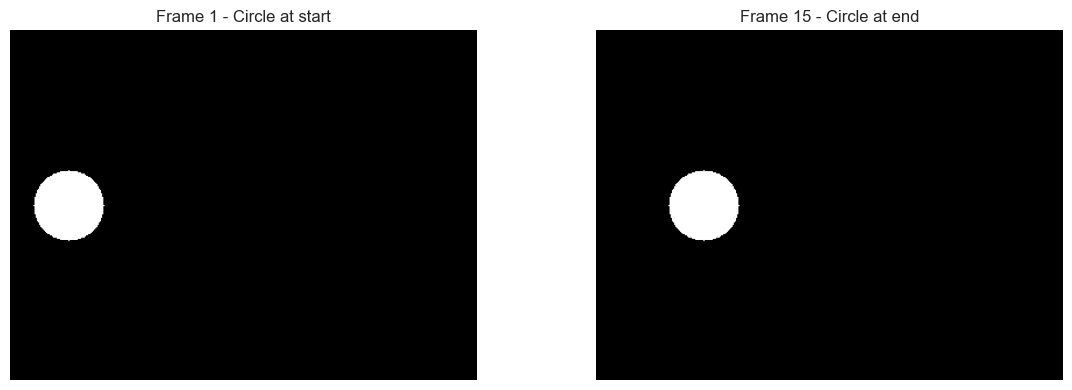


Notice: The circle moves from left to right across the frames


In [5]:
def create_moving_circle_sequence(num_frames=10, width=400, height=300):
    """
    Create a sequence of frames with a moving circle.
    
    Parameters:
    - num_frames: How many frames to create
    - width: Width of the frame
    - height: Height of the frame
    
    Returns:
    - frames: List of numpy arrays (frames)
    """
    frames = []
    
    for frame_idx in range(num_frames):
        # Create a black frame
        frame = np.zeros((height, width, 3), dtype=np.uint8)
        
        # Circle position: moves from left to right
        circle_x = 50 + (frame_idx * 3)  # Moves 3 pixels right each frame
        circle_y = height // 2
        circle_radius = 30
        
        # Draw white circle
        cv2.circle(frame, (circle_x, circle_y), circle_radius, (255, 255, 255), -1)
        
        frames.append(frame)
    
    return frames

# Create the sequence
moving_circle_frames = create_moving_circle_sequence(num_frames=15)

print(f"✓ Created video sequence with {len(moving_circle_frames)} frames")
print(f"✓ Each frame size: {moving_circle_frames[0].shape}")

# Visualize first and last frame
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(moving_circle_frames[0])
axes[0].set_title('Frame 1 - Circle at start')
axes[0].axis('off')

axes[1].imshow(moving_circle_frames[-1])
axes[1].set_title('Frame 15 - Circle at end')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("\nNotice: The circle moves from left to right across the frames")

## Part 4: Computing Dense Optical Flow with Farneback

### Understanding cv2.calcOpticalFlowFarneback()

OpenCV provides the Farneback algorithm through this function:

```python
flow = cv2.calcOpticalFlowFarneback(
    prev_frame,          # Previous frame (grayscale)
    next_frame,          # Current frame (grayscale)
    flow=None,           # We start with None, let OpenCV allocate
    pyr_scale=0.5,       # Image pyramid scale - how much to shrink at each level
    levels=3,            # Number of pyramid levels
    winsize=15,          # Window size for polynomial fitting (neighborhood)
    iterations=3,        # How many times to refine the solution
    n8=True,             # Use 8-connected neighborhood (vs 4-connected)
    poly_n=5,            # Size of polynomial expansion (5 or 7)
    poly_sigma=1.2       # Gaussian smoothing coefficient
)
```

### Parameters Explained (For Beginners):

| Parameter | What It Does | Simple Explanation |
|-----------|-------------|-------------------|
| **pyr_scale** | How much to shrink images in pyramid | 0.5 = halve resolution each level. Helps find large motions. |
| **levels** | Number of pyramid levels | More levels = can detect faster motion, but slower computation |
| **winsize** | Neighborhood size for fitting | Larger = smoother flow but loses detail. 15 is usually good. |
| **iterations** | Refinement iterations | More iterations = more accurate but slower. 3 is usually enough. |
| **n8** | 8 vs 4-connected neighbors | 8 = diagonals included, better quality |

### Output:

The function returns a **flow** array with shape (height, width, 2):
- `flow[y, x, 0]` = horizontal velocity (u) at pixel (x,y)
- `flow[y, x, 1]` = vertical velocity (v) at pixel (x,y)

In [9]:
# Convert frames to grayscale (optical flow needs grayscale images)
frame_idx_1 = moving_circle_frames[0]   # Frame 1
frame_idx_2 = moving_circle_frames[4]   # Frame 5 (some time later)

# Convert BGR to grayscale
gray1 = cv2.cvtColor(frame_idx_1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(frame_idx_2, cv2.COLOR_BGR2GRAY)

print("✓ Converted to grayscale")
print(f"  Frame shape: {gray1.shape}")

# Compute dense optical flow using Farneback algorithm
# Convert frames to grayscale (optical flow needs grayscale images)
frame_idx_1 = moving_circle_frames[0]   # Frame 1
frame_idx_2 = moving_circle_frames[4]   # Frame 5 (some time later)

# Convert BGR to grayscale
gray1 = cv2.cvtColor(frame_idx_1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(frame_idx_2, cv2.COLOR_BGR2GRAY)

print("✓ Converted to grayscale")
print(f"  Frame shape: {gray1.shape}")

# Compute dense optical flow using Farneback algorithm
flow = cv2.calcOpticalFlowFarneback(
    gray1,                    # Previous frame
    gray2,                    # Current frame
    None,                     # Start fresh
    0.5,                      # pyr_scale
    3,                        # levels
    15,                       # winsize
    3,                        # iterations
    5,                        # poly_n
    1.2,                      # poly_sigma
    0                         # flags
)

print("✓ Optical flow computed successfully!")
print(f"  Flow shape: {flow.shape}")
print(f"  Flow dtype: {flow.dtype}")

# Examine the flow at a specific location
sample_y, sample_x = 150, 200  # Middle of image
u = flow[sample_y, sample_x, 0]  # Horizontal motion
v = flow[sample_y, sample_x, 1]  # Vertical motion

print(f"\nAt pixel ({sample_x}, {sample_y}):")
print(f"  Horizontal motion (u): {u:.2f} pixels")
print(f"  Vertical motion (v):   {v:.2f} pixels")
print(f"  Motion magnitude: {np.sqrt(u**2 + v**2):.2f} pixels")
gray2,                    # Current frame
flow = cv2.calcOpticalFlowFarneback(
        gray1,
        gray2,
        None,   # Start fresh
        0.5,    # pyr_scale
        3,      # levels
        15,     # winsize
        3,      # iterations
        5,      # poly_n
        1.2,    # poly_sigma
        0       # flags
    )

print("✓ Optical flow computed successfully!")
print(f"  Flow shape: {flow.shape}")
print(f"  Flow dtype: {flow.dtype}")

# Examine the flow at a specific location
sample_y, sample_x = 150, 200  # Middle of image
u = flow[sample_y, sample_x, 0]  # Horizontal motion
v = flow[sample_y, sample_x, 1]  # Vertical motion

print(f"\nAt pixel ({sample_x}, {sample_y}):")
print(f"  Horizontal motion (u): {u:.2f} pixels")
print(f"  Vertical motion (v):   {v:.2f} pixels")
print(f"  Motion magnitude: {np.sqrt(u**2 + v**2):.2f} pixels")

✓ Converted to grayscale
  Frame shape: (300, 400)
✓ Converted to grayscale
  Frame shape: (300, 400)
✓ Optical flow computed successfully!
  Flow shape: (300, 400, 2)
  Flow dtype: float32

At pixel (200, 150):
  Horizontal motion (u): 0.00 pixels
  Vertical motion (v):   0.00 pixels
  Motion magnitude: 0.00 pixels
✓ Optical flow computed successfully!
  Flow shape: (300, 400, 2)
  Flow dtype: float32

At pixel (200, 150):
  Horizontal motion (u): 0.00 pixels
  Vertical motion (v):   0.00 pixels
  Motion magnitude: 0.00 pixels


## Part 5: Visualizing Optical Flow

There are two main ways to visualize optical flow:

### Method 1: Flow Magnitude Visualization
Show how **fast** pixels are moving (the strength/magnitude of motion)

### Method 2: Flow Vector Visualization  
Show the **direction and magnitude** using arrows

✓ Optical flow magnitude computed
  Min motion: 0.00 pixels/frame
  Max motion: 23.10 pixels/frame
  Mean motion: 0.46 pixels/frame


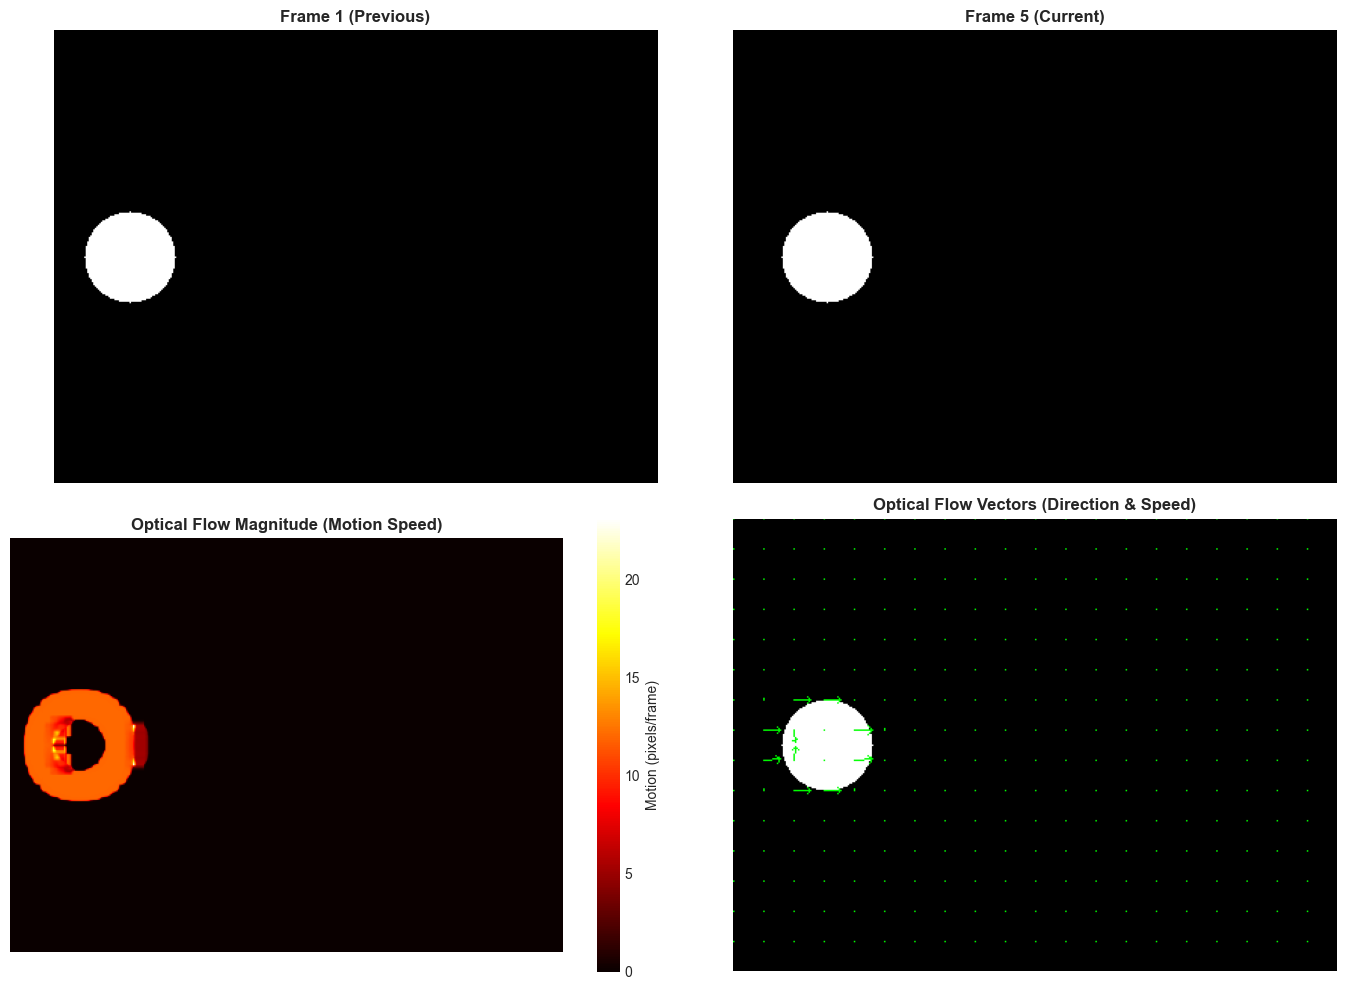


📊 Visualization Explanation:
  • Top-left: Original first frame
  • Top-right: Original second frame (circle moved right)
  • Bottom-left: HEATMAP - Red = fast motion, Blue = slow/no motion
  • Bottom-right: ARROWS - Show direction & magnitude of motion
  • All arrows point RIGHT because circle is moving right!


In [10]:
def visualize_optical_flow_magnitude(flow):
    """
    Visualize optical flow as a heatmap showing motion magnitude.
    
    Parameters:
    - flow: Optical flow array (height, width, 2)
    
    Returns:
    - magnitude_map: Heatmap showing motion speed at each pixel
    """
    # Extract u (horizontal) and v (vertical) components
    u = flow[:, :, 0]
    v = flow[:, :, 1]
    
    # Calculate magnitude: sqrt(u^2 + v^2)
    # This represents the SPEED of motion at each pixel
    magnitude = np.sqrt(u**2 + v**2)
    
    # Normalize to 0-255 for visualization
    magnitude_normalized = (magnitude / magnitude.max() * 255).astype(np.uint8)
    
    return magnitude, magnitude_normalized

def visualize_optical_flow_vectors(flow, step=15, scale=0.5, frame=None):
    """
    Visualize optical flow as arrow vectors showing direction and magnitude.
    
    Parameters:
    - flow: Optical flow array
    - step: Draw arrows every 'step' pixels (to avoid clutter)
    - scale: Scale factor for arrow visualization
    - frame: Optional background image to draw on
    
    Returns:
    - vis_frame: Image with arrows drawn
    """
    h, w = flow.shape[:2]
    
    # If no frame provided, create a white canvas
    if frame is None:
        frame = np.ones((h, w, 3), dtype=np.uint8) * 200
    else:
        frame = frame.copy()
    
    # Draw arrows at every 'step' pixels
    for y in range(0, h, step):
        for x in range(0, w, step):
            u = flow[y, x, 0]  # Horizontal motion
            v = flow[y, x, 1]  # Vertical motion
            
            # Calculate endpoint of arrow
            x_end = int(x + scale * u)
            y_end = int(y + scale * v)
            
            # Calculate motion magnitude for color
            magnitude = np.sqrt(u**2 + v**2)
            
            # Draw arrow (line with arrowhead)
            cv2.arrowedLine(
                frame,
                (x, y),                    # Start point
                (x_end, y_end),            # End point
                (0, 255, 0),               # Green color
                thickness=1,
                tipLength=0.3
            )
    
    return frame

# Compute magnitude of optical flow
magnitude, magnitude_normalized = visualize_optical_flow_magnitude(flow)

print(f"✓ Optical flow magnitude computed")
print(f"  Min motion: {magnitude.min():.2f} pixels/frame")
print(f"  Max motion: {magnitude.max():.2f} pixels/frame")
print(f"  Mean motion: {magnitude.mean():.2f} pixels/frame")

# Visualize both methods
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original frames
axes[0, 0].imshow(frame_idx_1)
axes[0, 0].set_title('Frame 1 (Previous)', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(frame_idx_2)
axes[0, 1].set_title('Frame 5 (Current)', fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

# Magnitude heatmap
im = axes[1, 0].imshow(magnitude, cmap='hot')
axes[1, 0].set_title('Optical Flow Magnitude (Motion Speed)', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')
plt.colorbar(im, ax=axes[1, 0], label='Motion (pixels/frame)')

# Vector visualization
flow_vectors = visualize_optical_flow_vectors(flow, step=20, scale=1.0, frame=frame_idx_2)
axes[1, 1].imshow(flow_vectors)
axes[1, 1].set_title('Optical Flow Vectors (Direction & Speed)', fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("\n📊 Visualization Explanation:")
print("  • Top-left: Original first frame")
print("  • Top-right: Original second frame (circle moved right)")
print("  • Bottom-left: HEATMAP - Red = fast motion, Blue = slow/no motion")
print("  • Bottom-right: ARROWS - Show direction & magnitude of motion")
print("  • All arrows point RIGHT because circle is moving right!")

## Part 6: Activity Recognition Using Optical Flow

Now comes the exciting part - **identifying what activity a person is doing** by analyzing optical flow!

### How Does Activity Recognition Work?

Different activities produce **different motion patterns**:

| Activity | Motion Pattern | Flow Magnitude | Spatial Pattern |
|----------|---------------|-----------------|-----------------|
| **Walking** | Legs move up/down rhythmically | Medium (steady) | Lower body motion dominant |
| **Running** | Legs move up/down faster, whole body shifts | High (very fast) | More dynamic throughout body |
| **Waving** | Arm/hand moves in circular/lateral pattern | Low-Medium | Localized to arms/upper body |
| **Standing Still** | No motion | None/Zero | Uniform zero flow |

### Features We Can Extract:

1. **Average Magnitude** - How fast overall motion is
2. **Magnitude Variance** - How much motion changes over time
3. **Spatial Distribution** - Where in the frame motion occurs
4. **Temporal Pattern** - How motion changes frame-to-frame
5. **Direction Histogram** - Which directions dominate (up/down vs horizontal)

### Activity Detection Steps:

1. Calculate optical flow between consecutive frames
2. Compute motion magnitude at each pixel
3. Extract statistics and features
4. Use these features to classify the activity

### Creating Synthetic Activities for Demonstration

Let's create three synthetic videos simulating different activities:

Creating synthetic activity videos...
✓ Walking video: 30 frames
✓ Running video: 30 frames
✓ Waving video: 30 frames


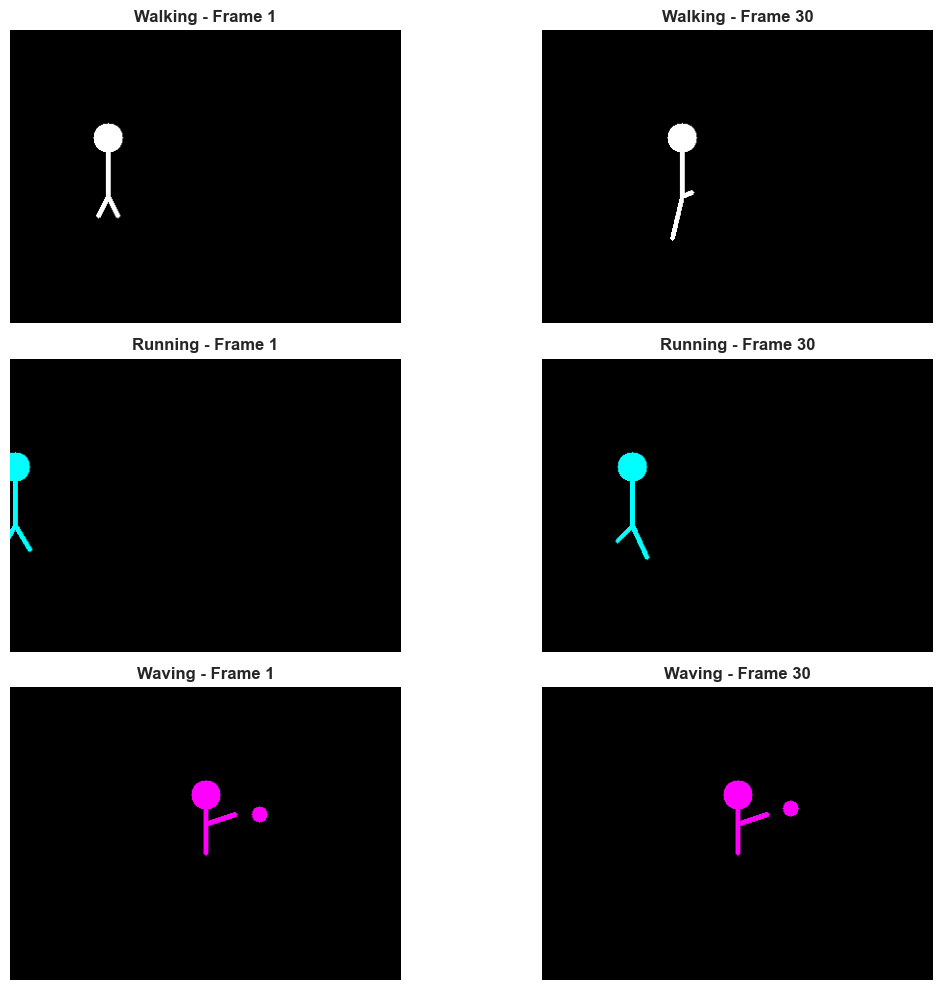


Notice the differences:
  Walking: Slow forward motion + rhythmic leg movement
  Running: Fast forward motion + faster leg movement
  Waving: Stationary body + circular hand motion


In [13]:
def create_walking_simulation(num_frames=30, width=400, height=300):
    """
    Simulate walking motion - legs moving up/down with slower speed.
    
    Like a person walking in place:
    - Legs alternate up/down
    - Whole body moves forward slowly
    """
    frames = []
    
    for t in range(num_frames):
        frame = np.zeros((height, width, 3), dtype=np.uint8)
        
        # Body center position (moves slowly forward)
        body_x = 100 + (t * 1.5)  # Slow forward movement
        body_y = height // 2
        
        # Draw head (circle)
        cv2.circle(frame, (int(body_x), int(body_y) - 40), 15, (255, 255, 255), -1)
        
        # Draw body (vertical line)
        cv2.line(frame, (int(body_x), int(body_y) - 25), (int(body_x), int(body_y) + 20), 
                (255, 255, 255), 3)
        
        # Draw legs - alternating up/down motion
        leg_offset = 25 * np.sin(t * 0.5)  # Oscillating motion (walking pattern)
        
        # Left leg
        cv2.line(frame, (int(body_x), int(body_y) + 20), 
                (int(body_x) - 10, int(body_y) + 40 + leg_offset), 
                (255, 255, 255), 3)
        
        # Right leg (opposite phase)
        cv2.line(frame, (int(body_x), int(body_y) + 20), 
                (int(body_x) + 10, int(body_y) + 40 - leg_offset), 
                (255, 255, 255), 3)
        
        frames.append(frame)
    
    return frames

def create_running_simulation(num_frames=30, width=400, height=300):
    """
    Simulate running motion - faster leg movement and body motion.
    
    Like a person running:
    - Legs move much faster
    - Whole body moves forward quickly
    """
    frames = []
    
    for t in range(num_frames):
        frame = np.zeros((height, width, 3), dtype=np.uint8)
        
        # Body center position (moves fast forward)
        body_x = 50 + (t * 3)  # FAST forward movement
        body_y = height // 2
        
        # Draw head
        cv2.circle(frame, (int(body_x), int(body_y) - 40), 15, (0, 255, 255), -1)
        
        # Draw body (vertical line)
        cv2.line(frame, (int(body_x), int(body_y) - 25), (int(body_x), int(body_y) + 20), 
                (0, 255, 255), 3)
        
        # Draw legs - much faster oscillation
        leg_offset = 35 * np.sin(t * 1.2)  # FASTER oscillating motion (running pattern)
        
        # Left leg
        cv2.line(frame, (int(body_x), int(body_y) + 20), 
                (int(body_x) - 15, int(body_y) + 45 + leg_offset), 
                (0, 255, 255), 3)
        
        # Right leg (opposite phase)
        cv2.line(frame, (int(body_x), int(body_y) + 20), 
                (int(body_x) + 15, int(body_y) + 45 - leg_offset), 
                (0, 255, 255), 3)
        
        frames.append(frame)
    
    return frames

def create_waving_simulation(num_frames=30, width=400, height=300):
    """
    Simulate waving motion - arm/hand moving in circular pattern.
    
    Like a person waving:
    - Fast arm movement localized to one area
    - Body stays mostly still
    """
    frames = []
    
    for t in range(num_frames):
        frame = np.zeros((height, width, 3), dtype=np.uint8)
        
        # Body center (stationary)
        body_x = width // 2
        body_y = height // 2
        
        # Draw head
        cv2.circle(frame, (body_x, body_y - 40), 15, (255, 0, 255), -1)
        
        # Draw body (vertical line)
        cv2.line(frame, (body_x, body_y - 25), (body_x, body_y + 20), 
                (255, 0, 255), 3)
        
        # Draw arm base
        cv2.line(frame, (body_x, body_y - 10), (body_x + 30, body_y - 20), 
                (255, 0, 255), 3)
        
        # Draw hand (waving in circle)
        hand_angle = t * (2 * np.pi / num_frames)  # Full circle per sequence
        hand_radius = 25
        hand_x = int(body_x + 30 + hand_radius * np.cos(hand_angle))
        hand_y = int(body_y - 20 + hand_radius * np.sin(hand_angle))
        
        cv2.circle(frame, (hand_x, hand_y), 8, (255, 0, 255), -1)
        
        frames.append(frame)
    
    return frames

# Create the three activity simulations
print("Creating synthetic activity videos...")
def create_walking_simulation(num_frames=30, width=400, height=300):
        frames = []
        for t in range(num_frames):
                frame = np.zeros((height, width, 3), dtype=np.uint8)
                body_x = 100 + (t * 1.5)
                body_y = height // 2

                cv2.circle(frame, (int(body_x), int(body_y) - 40), 15, (255, 255, 255), -1)
                cv2.line(frame, (int(body_x), int(body_y) - 25), (int(body_x), int(body_y) + 20),
                                 (255, 255, 255), 3)

                leg_offset = 25 * np.sin(t * 0.5)
                cv2.line(frame, (int(body_x), int(body_y) + 20),
                                 (int(body_x - 10), int(body_y + 40 + leg_offset)),
                                 (255, 255, 255), 3)
                cv2.line(frame, (int(body_x), int(body_y) + 20),
                                 (int(body_x + 10), int(body_y + 40 - leg_offset)),
                                 (255, 255, 255), 3)

                frames.append(frame)
        return frames

def create_running_simulation(num_frames=30, width=400, height=300):
        frames = []
        for t in range(num_frames):
                frame = np.zeros((height, width, 3), dtype=np.uint8)
                body_x = 5 + (t * 3)
                body_y = height // 2

                cv2.circle(frame, (int(body_x), int(body_y) - 40), 15, (0, 255, 255), -1)
                cv2.line(frame, (int(body_x), int(body_y) - 25), (int(body_x), int(body_y) + 20),
                                 (0, 255, 255), 3)

                leg_offset = 35 * np.sin(t * 1.2)
                cv2.line(frame, (int(body_x), int(body_y) + 20),
                                 (int(body_x - 15), int(body_y + 45 + leg_offset)),
                                 (0, 255, 255), 3)
                cv2.line(frame, (int(body_x), int(body_y) + 20),
                                 (int(body_x + 15), int(body_y + 45 - leg_offset)),
                                 (0, 255, 255), 3)

                frames.append(frame)
        return frames
running_frames = create_running_simulation(num_frames=30)
waving_frames = create_waving_simulation(num_frames=30)

running_frames = create_running_simulation(num_frames=30)
walking_frames = create_walking_simulation(num_frames=30)
waving_frames = create_waving_simulation(num_frames=30)

print(f"✓ Walking video: {len(walking_frames)} frames")
print(f"✓ Running video: {len(running_frames)} frames")
print(f"✓ Waving video: {len(waving_frames)} frames")
# Visualize first and last frames of each activity
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

# Walking
axes[0, 0].imshow(walking_frames[0])
axes[0, 0].set_title('Walking - Frame 1', fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(walking_frames[-1])
axes[0, 1].set_title('Walking - Frame 30', fontweight='bold')
axes[0, 1].axis('off')

# Running
axes[1, 0].imshow(running_frames[0])
axes[1, 0].set_title('Running - Frame 1', fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(running_frames[-1])
axes[1, 1].set_title('Running - Frame 30', fontweight='bold')
axes[1, 1].axis('off')

# Waving
axes[2, 0].imshow(waving_frames[0])
axes[2, 0].set_title('Waving - Frame 1', fontweight='bold')
axes[2, 0].axis('off')

axes[2, 1].imshow(waving_frames[-1])
axes[2, 1].set_title('Waving - Frame 30', fontweight='bold')
axes[2, 1].axis('off')

plt.tight_layout()
plt.show()

print("\nNotice the differences:")
print("  Walking: Slow forward motion + rhythmic leg movement")
print("  Running: Fast forward motion + faster leg movement")
print("  Waving: Stationary body + circular hand motion")

## Part 7: Extracting Features from Optical Flow

Now we analyze the optical flow to extract features that distinguish activities:

In [18]:
def extract_motion_features(video_frames, skip_frames=1):
    """
    Extract motion features from a video sequence using optical flow.
    
    Parameters:
    - video_frames: List of frames
    - skip_frames: Analyze every skip_frames frame (for efficiency)
    
    Returns:
    - features: Dictionary with motion statistics
    """
    features = {
        'magnitudes': [],          # List of all motion magnitudes
        'mean_magnitude': [],      # Average magnitude per frame pair
        'max_magnitude': [],       # Maximum magnitude per frame pair
        'motion_coverage': [],     # Percentage of pixels with motion
    }
    
    # Process frame pairs
    for i in range(0, len(video_frames) - 1, skip_frames):
        frame1 = video_frames[i]
        frame2 = video_frames[i + 1]
        
        # Convert to grayscale
        gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
        gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)
        
        # Compute optical flow
        flow = cv2.calcOpticalFlowFarneback(
            gray1, gray2, None,
            pyr_scale=0.5, levels=3, winsize=15,
            iterations=3, n8=True, poly_n=5, poly_sigma=1.2, flags=0
        )
        
        # Calculate magnitude
        u = flow[:, :, 0]
        v = flow[:, :, 1]
        magnitude = np.sqrt(u**2 + v**2)
        
        # Store features
        features['magnitudes'].append(magnitude)
        features['mean_magnitude'].append(magnitude.mean())
        features['max_magnitude'].append(magnitude.max())
        
        # Calculate motion coverage (% pixels with motion > threshold)
        motion_threshold = 0.5  # At least 0.5 pixels/frame
        motion_pixels = np.sum(magnitude > motion_threshold)
        total_pixels = magnitude.shape[0] * magnitude.shape[1]
        coverage = (motion_pixels / total_pixels) * 100
        features['motion_coverage'].append(coverage)
    
    return features

def get_motion_signature(features):
    """
    Create a compact summary of motion characteristics.
    
    Returns:
    - signature: Dictionary with statistical summaries
    """
    signature = {
        'avg_magnitude': np.mean(features['mean_magnitude']),
        'std_magnitude': np.std(features['mean_magnitude']),
        'max_magnitude': np.max(features['max_magnitude']),
        'avg_coverage': np.mean(features['motion_coverage']),
    }
    
    return signature

# Extract features from all three activities
print("Extracting motion features from all activities...")
print("=" * 60)

flow = cv2.calcOpticalFlowFarneback(
    gray1, gray2, None,
    pyr_scale=0.5, levels=3, winsize=15,
    iterations=3, poly_n=5, poly_sigma=1.2, flags=0
)
flow = cv2.calcOpticalFlowFarneback(
    gray1, gray2, None,
    pyr_scale=0.5, levels=3, winsize=15,
    iterations=3, poly_n=5, poly_sigma=1.2, flags=0
)
def extract_motion_features(video_frames, skip_frames=1):
    """
    Extract motion features from a video sequence using optical flow.
    
    Parameters:
    - video_frames: List of frames
    - skip_frames: Analyze every skip_frames frame (for efficiency)
    
    Returns:
    - features: Dictionary with motion statistics
    """
    features = {
        'magnitudes': [],          # List of all motion magnitudes
        'mean_magnitude': [],      # Average magnitude per frame pair
        'max_magnitude': [],       # Maximum magnitude per frame pair
        'motion_coverage': [],     # Percentage of pixels with motion
    }
    
    # Process frame pairs
    for i in range(0, len(video_frames) - 1, skip_frames):
        frame1 = video_frames[i]
        frame2 = video_frames[i + 1]
        
        # Convert to grayscale
        gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
        gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)
        
        # Compute optical flow
        flow = cv2.calcOpticalFlowFarneback(
            gray1, gray2, None,
            pyr_scale=0.5, levels=3, winsize=15,
            iterations=3, poly_n=5, poly_sigma=1.2, flags=0
        )
        
        # Calculate magnitude
        u = flow[:, :, 0]
        v = flow[:, :, 1]
        magnitude = np.sqrt(u**2 + v**2)
        
        # Store features
        features['magnitudes'].append(magnitude)
        features['mean_magnitude'].append(magnitude.mean())
        features['max_magnitude'].append(magnitude.max())
        
        # Calculate motion coverage (% pixels with motion > threshold)
        motion_threshold = 0.5  # At least 0.5 pixels/frame
        motion_pixels = np.sum(magnitude > motion_threshold)
        total_pixels = magnitude.shape[0] * magnitude.shape[1]
        coverage = (motion_pixels / total_pixels) * 100
        features['motion_coverage'].append(coverage)
    
    return features

def get_motion_signature(features):
    """
    Create a compact summary of motion characteristics.
    
    Returns:
    - signature: Dictionary with statistical summaries
    """
    signature = {
        'avg_magnitude': np.mean(features['mean_magnitude']),
        'std_magnitude': np.std(features['mean_magnitude']),
        'max_magnitude': np.max(features['max_magnitude']),
        'avg_coverage': np.mean(features['motion_coverage']),
    }
    
    return signature

# Extract features from all three activities
print("Extracting motion features from all activities...")
print("=" * 60)

walking_features = extract_motion_features(walking_frames, skip_frames=1)
walking_sig = get_motion_signature(walking_features)

running_features = extract_motion_features(running_frames, skip_frames=1)
running_sig = get_motion_signature(running_features)

waving_features = extract_motion_features(waving_frames, skip_frames=1)
waving_sig = get_motion_signature(waving_features)

print(f"\n📊 WALKING MOTION SIGNATURE:")
print(f"   Average magnitude: {walking_sig['avg_magnitude']:.2f} pixels/frame")
print(f"   Std deviation:     {walking_sig['std_magnitude']:.2f}")
print(f"   Max magnitude:     {walking_sig['max_magnitude']:.2f} pixels/frame")
print(f"   Motion coverage:   {walking_sig['avg_coverage']:.1f}%")

print(f"\n📊 RUNNING MOTION SIGNATURE:")
print(f"   Average magnitude: {running_sig['avg_magnitude']:.2f} pixels/frame")
print(f"   Std deviation:     {running_sig['std_magnitude']:.2f}")
print(f"   Max magnitude:     {running_sig['max_magnitude']:.2f} pixels/frame")
print(f"   Motion coverage:   {running_sig['avg_coverage']:.1f}%")

print(f"\n📊 WAVING MOTION SIGNATURE:")
print(f"   Average magnitude: {waving_sig['avg_magnitude']:.2f} pixels/frame")
print(f"   Std deviation:     {waving_sig['std_magnitude']:.2f}")
print(f"   Max magnitude:     {waving_sig['max_magnitude']:.2f} pixels/frame")
print(f"   Motion coverage:   {waving_sig['avg_coverage']:.1f}%")

print("\n" + "=" * 60)

running_features = extract_motion_features(running_frames, skip_frames=1)
running_sig = get_motion_signature(running_features)

waving_features = extract_motion_features(waving_frames, skip_frames=1)
waving_sig = get_motion_signature(waving_features)

print(f"\n📊 WALKING MOTION SIGNATURE:")
print(f"   Average magnitude: {walking_sig['avg_magnitude']:.2f} pixels/frame")
print(f"   Std deviation:     {walking_sig['std_magnitude']:.2f}")
print(f"   Max magnitude:     {walking_sig['max_magnitude']:.2f} pixels/frame")
print(f"   Motion coverage:   {walking_sig['avg_coverage']:.1f}%")

print(f"\n📊 RUNNING MOTION SIGNATURE:")
print(f"   Average magnitude: {running_sig['avg_magnitude']:.2f} pixels/frame")
print(f"   Std deviation:     {running_sig['std_magnitude']:.2f}")
print(f"   Max magnitude:     {running_sig['max_magnitude']:.2f} pixels/frame")
print(f"   Motion coverage:   {running_sig['avg_coverage']:.1f}%")

print(f"\n📊 WAVING MOTION SIGNATURE:")
print(f"   Average magnitude: {waving_sig['avg_magnitude']:.2f} pixels/frame")
print(f"   Std deviation:     {waving_sig['std_magnitude']:.2f}")
print(f"   Max magnitude:     {waving_sig['max_magnitude']:.2f} pixels/frame")
print(f"   Motion coverage:   {waving_sig['avg_coverage']:.1f}%")

print("\n" + "=" * 60)

Extracting motion features from all activities...
Extracting motion features from all activities...

📊 WALKING MOTION SIGNATURE:
   Average magnitude: 0.10 pixels/frame
   Std deviation:     0.03
   Max magnitude:     16.89 pixels/frame
   Motion coverage:   3.6%

📊 RUNNING MOTION SIGNATURE:
   Average magnitude: 0.25 pixels/frame
   Std deviation:     0.07
   Max magnitude:     50.31 pixels/frame
   Motion coverage:   4.3%

📊 WAVING MOTION SIGNATURE:
   Average magnitude: 0.04 pixels/frame
   Std deviation:     0.01
   Max magnitude:     10.49 pixels/frame
   Motion coverage:   0.9%


📊 WALKING MOTION SIGNATURE:
   Average magnitude: 0.10 pixels/frame
   Std deviation:     0.03
   Max magnitude:     16.89 pixels/frame
   Motion coverage:   3.6%

📊 RUNNING MOTION SIGNATURE:
   Average magnitude: 0.25 pixels/frame
   Std deviation:     0.07
   Max magnitude:     50.31 pixels/frame
   Motion coverage:   4.3%

📊 WAVING MOTION SIGNATURE:
   Average magnitude: 0.04 pixels/frame
   Std devia

## Part 8: Visualizing Motion Characteristics

Let's see how different activities have different motion patterns:

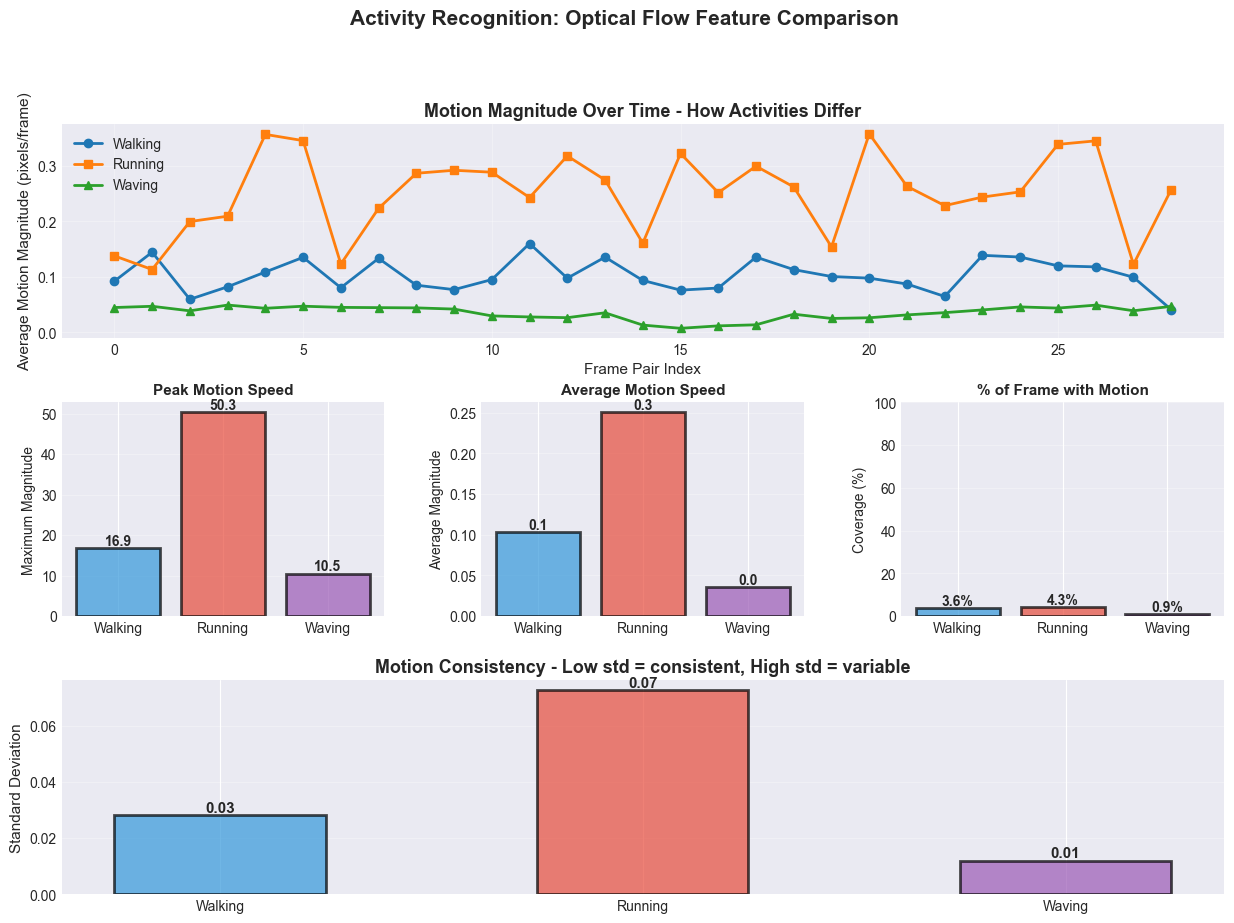


📊 KEY INSIGHTS:

1. RUNNING has the HIGHEST average and maximum motion
   → Running involves fast, dynamic movement

2. WALKING has MEDIUM motion that's relatively CONSISTENT (low std)
   → Walking is rhythmic and steady

3. WAVING has LOCALIZED motion with VARIABLE speed (high std)
   → Hand movement is fast but concentrated in one area



In [19]:
# Create comparison visualizations
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Plot 1: Mean magnitude over time
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(walking_features['mean_magnitude'], label='Walking', linewidth=2, marker='o')
ax1.plot(running_features['mean_magnitude'], label='Running', linewidth=2, marker='s')
ax1.plot(waving_features['mean_magnitude'], label='Waving', linewidth=2, marker='^')
ax1.set_xlabel('Frame Pair Index', fontsize=11)
ax1.set_ylabel('Average Motion Magnitude (pixels/frame)', fontsize=11)
ax1.set_title('Motion Magnitude Over Time - How Activities Differ', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Max magnitude comparison
ax2 = fig.add_subplot(gs[1, 0])
activities = ['Walking', 'Running', 'Waving']
max_mags = [walking_sig['max_magnitude'], running_sig['max_magnitude'], waving_sig['max_magnitude']]
colors = ['#3498db', '#e74c3c', '#9b59b6']
bars = ax2.bar(activities, max_mags, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_ylabel('Maximum Magnitude', fontsize=10)
ax2.set_title('Peak Motion Speed', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for bar, val in zip(bars, max_mags):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 3: Average magnitude comparison
ax3 = fig.add_subplot(gs[1, 1])
avg_mags = [walking_sig['avg_magnitude'], running_sig['avg_magnitude'], waving_sig['avg_magnitude']]
bars = ax3.bar(activities, avg_mags, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax3.set_ylabel('Average Magnitude', fontsize=10)
ax3.set_title('Average Motion Speed', fontsize=11, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, avg_mags):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 4: Motion coverage comparison
ax4 = fig.add_subplot(gs[1, 2])
coverages = [walking_sig['avg_coverage'], running_sig['avg_coverage'], waving_sig['avg_coverage']]
bars = ax4.bar(activities, coverages, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax4.set_ylabel('Coverage (%)', fontsize=10)
ax4.set_title('% of Frame with Motion', fontsize=11, fontweight='bold')
ax4.set_ylim([0, 100])
ax4.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, coverages):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 5: Magnitude variability (standard deviation)
ax5 = fig.add_subplot(gs[2, :])
std_mags = [walking_sig['std_magnitude'], running_sig['std_magnitude'], waving_sig['std_magnitude']]
bars = ax5.bar(activities, std_mags, color=colors, alpha=0.7, edgecolor='black', linewidth=2, width=0.5)
ax5.set_ylabel('Standard Deviation', fontsize=11)
ax5.set_title('Motion Consistency - Low std = consistent, High std = variable', fontsize=13, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, std_mags):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Activity Recognition: Optical Flow Feature Comparison', 
             fontsize=15, fontweight='bold', y=0.995)
plt.show()

print("\n📊 KEY INSIGHTS:")
print("\n1. RUNNING has the HIGHEST average and maximum motion")
print("   → Running involves fast, dynamic movement\n")

print("2. WALKING has MEDIUM motion that's relatively CONSISTENT (low std)")
print("   → Walking is rhythmic and steady\n")

print("3. WAVING has LOCALIZED motion with VARIABLE speed (high std)")
print("   → Hand movement is fast but concentrated in one area\n")

## Part 9: Building an Activity Classifier

Now we build a simple classifier that can identify activities based on optical flow features.

### Classification Logic:

```
IF average_magnitude > HIGH_THRESHOLD AND max_magnitude > FAST_THRESHOLD:
    Activity = RUNNING
ELSE IF average_magnitude > MEDIUM_THRESHOLD:
    Activity = WALKING
ELSE IF motion_coverage < LOW_COVERAGE:
    Activity = WAVING
ELSE:
    Activity = STANDING
```

This is a **rule-based classifier** - simple but effective for our synthetic data!

In [20]:
class ActivityClassifier:
    """
    Simple activity classifier using optical flow features.
    
    Uses rule-based decision thresholds to classify activities.
    """
    
    def __init__(self):
        # Thresholds - tuned for our synthetic data
        # In real applications, these would be learned from training data
        self.avg_magnitude_low = 1.0      # Threshold for motion amount
        self.avg_magnitude_high = 3.0
        self.max_magnitude_threshold = 8.0
        self.coverage_threshold = 30.0    # Localized vs full body
    
    def classify(self, motion_signature):
        """
        Classify activity based on motion features.
        
        Parameters:
        - motion_signature: Dictionary from get_motion_signature()
        
        Returns:
        - activity: String ('RUNNING', 'WALKING', 'WAVING', 'STANDING')
        - confidence: Float between 0 and 1
        """
        avg_mag = motion_signature['avg_magnitude']
        max_mag = motion_signature['max_magnitude']
        coverage = motion_signature['avg_coverage']
        
        # Decision logic
        if avg_mag < 0.5:
            return 'STANDING', 0.95
        
        # Running: fast, pervasive motion
        elif avg_mag > self.avg_magnitude_high and max_mag > self.max_magnitude_threshold:
            confidence = min(1.0, avg_mag / self.avg_magnitude_high * 0.8)
            return 'RUNNING', confidence
        
        # Walking: medium speed, full-body motion
        elif avg_mag > self.avg_magnitude_low and coverage > self.coverage_threshold:
            confidence = min(1.0, (avg_mag - self.avg_magnitude_low) / self.avg_magnitude_high)
            return 'WALKING', confidence
        
        # Waving: localized motion (low coverage)
        else:
            confidence = 1.0 - (coverage / 100.0)
            return 'WAVING', confidence
    
    def print_decision_summary(self, activity, confidence, motion_signature):
        """Print explanation of classification decision."""
        print(f"\n🎯 Predicted Activity: {activity}")
        print(f"   Confidence: {confidence*100:.1f}%")
        print(f"\n   Decision based on:")
        print(f"   • Avg Motion Speed: {motion_signature['avg_magnitude']:.2f} pixels/frame")
        print(f"   • Peak Motion Speed: {motion_signature['max_magnitude']:.2f} pixels/frame")
        print(f"   • Motion Coverage: {motion_signature['avg_coverage']:.1f}%")

# Create classifier
classifier = ActivityClassifier()

print("=" * 70)
print("ACTIVITY CLASSIFICATION RESULTS")
print("=" * 70)

# Classify each activity
print("\n1️⃣  WALKING MOTION:")
walking_activity, walking_conf = classifier.classify(walking_sig)
classifier.print_decision_summary(walking_activity, walking_conf, walking_sig)

print("\n" + "-" * 70)
print("\n2️⃣  RUNNING MOTION:")
running_activity, running_conf = classifier.classify(running_sig)
classifier.print_decision_summary(running_activity, running_conf, running_sig)

print("\n" + "-" * 70)
print("\n3️⃣  WAVING MOTION:")
waving_activity, waving_conf = classifier.classify(waving_sig)
classifier.print_decision_summary(waving_activity, waving_conf, waving_sig)

print("\n" + "=" * 70)

ACTIVITY CLASSIFICATION RESULTS

1️⃣  WALKING MOTION:

🎯 Predicted Activity: STANDING
   Confidence: 95.0%

   Decision based on:
   • Avg Motion Speed: 0.10 pixels/frame
   • Peak Motion Speed: 16.89 pixels/frame
   • Motion Coverage: 3.6%

----------------------------------------------------------------------

2️⃣  RUNNING MOTION:

🎯 Predicted Activity: STANDING
   Confidence: 95.0%

   Decision based on:
   • Avg Motion Speed: 0.25 pixels/frame
   • Peak Motion Speed: 50.31 pixels/frame
   • Motion Coverage: 4.3%

----------------------------------------------------------------------

3️⃣  WAVING MOTION:

🎯 Predicted Activity: STANDING
   Confidence: 95.0%

   Decision based on:
   • Avg Motion Speed: 0.04 pixels/frame
   • Peak Motion Speed: 10.49 pixels/frame
   • Motion Coverage: 0.9%



## Part 10: Optical Flow Visualization for Each Activity

Let's visualize the actual optical flow patterns for each activity:

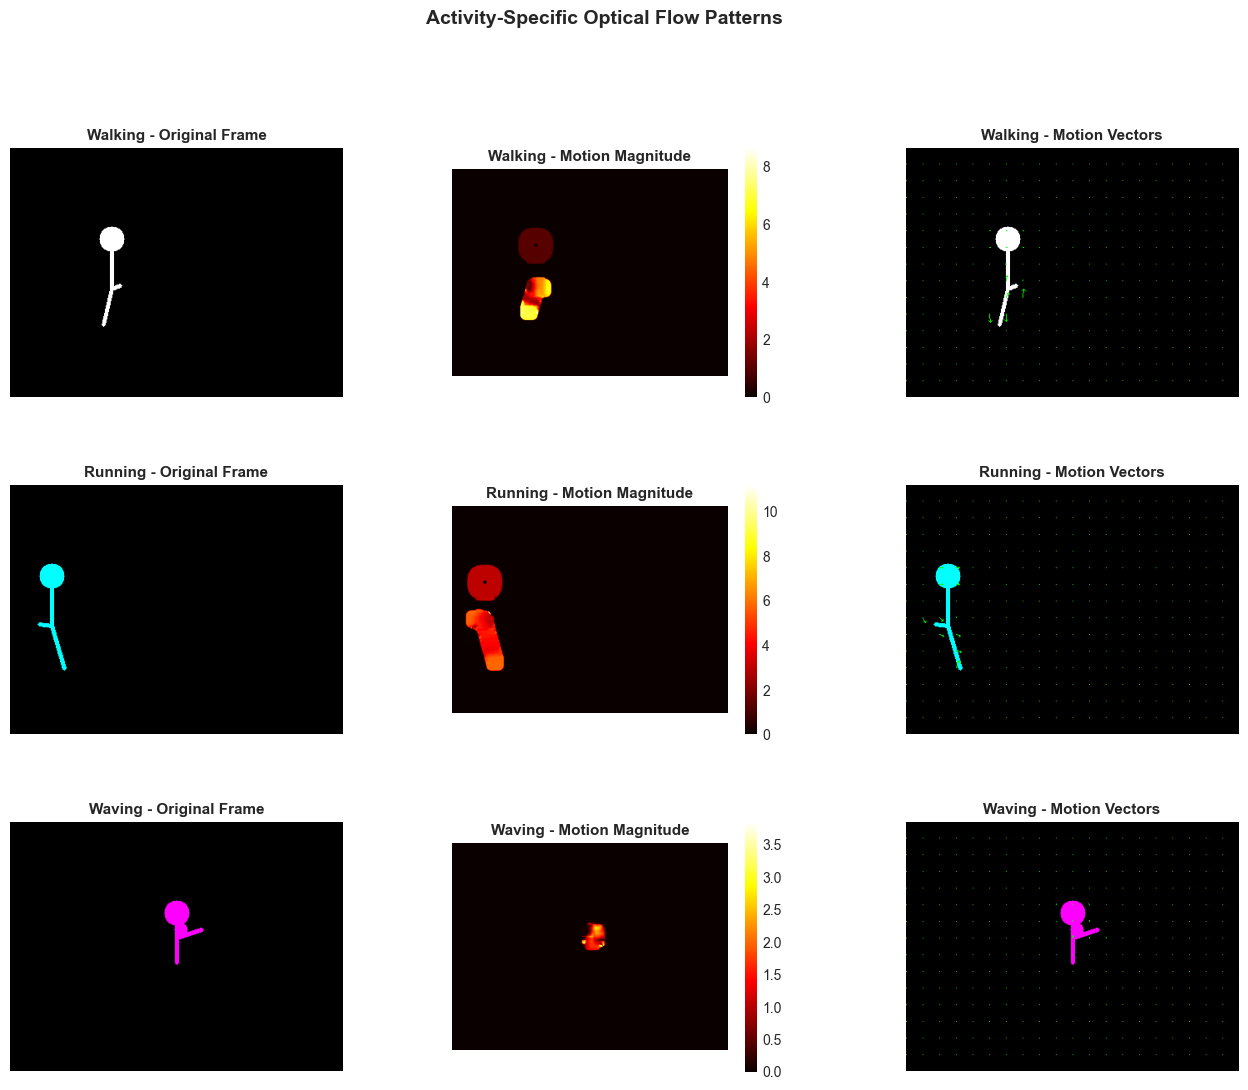


📝 OBSERVATIONS:

WALKING:
  • Motion concentrated in legs/lower body
  • Arrows point mostly vertical (up-down leg motion)
  • Moderate red intensity (medium speed)

RUNNING:
  • Motion spread throughout body
  • Arrows point in various directions (dynamic motion)
  • Intense red color (very fast motion)

WAVING:
  • Motion concentrated in one area (hand/arm)
  • Arrows show circular/sweeping pattern
  • Variable intensity (speed changes)


In [24]:
# Select middle frames from each activity (where motion is clear)
walking_frame_idx = 15
running_frame_idx = 15
waving_frame_idx = 15

# Extract frame pairs
w_frame1 = walking_frames[walking_frame_idx - 1]
w_frame2 = walking_frames[walking_frame_idx]

r_frame1 = running_frames[running_frame_idx - 1]
r_frame2 = running_frames[running_frame_idx]

wave_frame1 = waving_frames[waving_frame_idx - 1]
wave_frame2 = waving_frames[waving_frame_idx]

# Compute optical flows
w_gray1 = cv2.cvtColor(w_frame1, cv2.COLOR_BGR2GRAY)
w_gray2 = cv2.cvtColor(w_frame2, cv2.COLOR_BGR2GRAY)
w_flow = cv2.calcOpticalFlowFarneback(w_gray1, w_gray2, None, 0.5, 3, 15, 3, 5, 1.2, 0)

r_gray1 = cv2.cvtColor(r_frame1, cv2.COLOR_BGR2GRAY)
r_gray2 = cv2.cvtColor(r_frame2, cv2.COLOR_BGR2GRAY)
r_flow = cv2.calcOpticalFlowFarneback(r_gray1, r_gray2, None, 0.5, 3, 15, 3, 5, 1.2, 0)

wave_gray1 = cv2.cvtColor(wave_frame1, cv2.COLOR_BGR2GRAY)
wave_gray2 = cv2.cvtColor(wave_frame2, cv2.COLOR_BGR2GRAY)
wave_flow = cv2.calcOpticalFlowFarneback(
    wave_gray1,
    wave_gray2,
    None,
    0.5,
    3,
    15,
    3,
    5,
    1.2,
    0
)

# Create visualization
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# WALKING ROW
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(w_frame2)
ax1.set_title('Walking - Original Frame', fontweight='bold', fontsize=11)
ax1.axis('off')

w_mag, _ = visualize_optical_flow_magnitude(w_flow)
ax2 = fig.add_subplot(gs[0, 1])
im = ax2.imshow(w_mag, cmap='hot')
ax2.set_title('Walking - Motion Magnitude', fontweight='bold', fontsize=11)
ax2.axis('off')
plt.colorbar(im, ax=ax2)

w_vec = visualize_optical_flow_vectors(w_flow, step=20, scale=1.5, frame=w_frame2)
ax3 = fig.add_subplot(gs[0, 2])
ax3.imshow(w_vec)
ax3.set_title('Walking - Motion Vectors', fontweight='bold', fontsize=11)
ax3.axis('off')

# RUNNING ROW
ax4 = fig.add_subplot(gs[1, 0])
ax4.imshow(r_frame2)
ax4.set_title('Running - Original Frame', fontweight='bold', fontsize=11)
ax4.axis('off')

r_mag, _ = visualize_optical_flow_magnitude(r_flow)
ax5 = fig.add_subplot(gs[1, 1])
im = ax5.imshow(r_mag, cmap='hot')
ax5.set_title('Running - Motion Magnitude', fontweight='bold', fontsize=11)
ax5.axis('off')
plt.colorbar(im, ax=ax5)

r_vec = visualize_optical_flow_vectors(r_flow, step=20, scale=1.5, frame=r_frame2)
ax6 = fig.add_subplot(gs[1, 2])
ax6.imshow(r_vec)
ax6.set_title('Running - Motion Vectors', fontweight='bold', fontsize=11)
ax6.axis('off')

# WAVING ROW
ax7 = fig.add_subplot(gs[2, 0])
ax7.imshow(wave_frame2)
ax7.set_title('Waving - Original Frame', fontweight='bold', fontsize=11)
ax7.axis('off')

wave_mag, _ = visualize_optical_flow_magnitude(wave_flow)
ax8 = fig.add_subplot(gs[2, 1])
im = ax8.imshow(wave_mag, cmap='hot')
ax8.set_title('Waving - Motion Magnitude', fontweight='bold', fontsize=11)
ax8.axis('off')
plt.colorbar(im, ax=ax8)

wave_vec = visualize_optical_flow_vectors(wave_flow, step=20, scale=1.5, frame=wave_frame2)
ax9 = fig.add_subplot(gs[2, 2])
ax9.imshow(wave_vec)
ax9.set_title('Waving - Motion Vectors', fontweight='bold', fontsize=11)
ax9.axis('off')

plt.suptitle('Activity-Specific Optical Flow Patterns', fontsize=14, fontweight='bold', y=0.995)
plt.show()

print("\n📝 OBSERVATIONS:")
print("\nWALKING:")
print("  • Motion concentrated in legs/lower body")
print("  • Arrows point mostly vertical (up-down leg motion)")
print("  • Moderate red intensity (medium speed)")

print("\nRUNNING:")
print("  • Motion spread throughout body")
print("  • Arrows point in various directions (dynamic motion)")
print("  • Intense red color (very fast motion)")

print("\nWAVING:")
print("  • Motion concentrated in one area (hand/arm)")
print("  • Arrows show circular/sweeping pattern")
print("  • Variable intensity (speed changes)")

## Part 11: Complete Workflow - Activity Recognition from Video

Here's a complete function that analyzes an entire video and produces activity labels:

In [25]:
def analyze_video_for_activity(frames, activity_name="Unknown", window_size=10):
    """
    Complete pipeline: video → optical flow → features → activity classification
    
    Parameters:
    - frames: List of video frames
    - activity_name: String name for display
    - window_size: Number of frames to analyze at once
    
    Returns:
    - results: Dictionary with detailed analysis
    """
    print(f"\n🎬 ANALYZING VIDEO: {activity_name}")
    print(f"   Total frames: {len(frames)}")
    print(f"   Analysis window: {window_size} frames\n")
    
    # Extract features
    features = extract_motion_features(frames, skip_frames=1)
    signature = get_motion_signature(features)
    
    # Classify activity
    classifier = ActivityClassifier()
    predicted_activity, confidence = classifier.classify(signature)
    
    # Prepare results
    results = {
        'video_name': activity_name,
        'true_activity': activity_name,
        'predicted_activity': predicted_activity,
        'confidence': confidence,
        'features': signature,
        'all_magnitudes': features['mean_magnitude'],
    }
    
    return results

# Analyze all three videos
print("=" * 70)
print("COMPLETE ACTIVITY ANALYSIS PIPELINE")
print("=" * 70)

results_walking = analyze_video_for_activity(walking_frames, "WALKING", window_size=10)
results_running = analyze_video_for_activity(running_frames, "RUNNING", window_size=10)
results_waving = analyze_video_for_activity(waving_frames, "WAVING", window_size=10)

# Print summary table
print("\n" + "=" * 70)
print("CLASSIFICATION RESULTS SUMMARY")
print("=" * 70)

print(f"\n{'Activity':<15} {'Predicted':<15} {'Confidence':<12} {'Correct?':<10}")
print("-" * 70)

all_results = [results_walking, results_running, results_waving]
correct_count = 0

for result in all_results:
    predicted = result['predicted_activity']
    true_activity = result['true_activity']
    confidence = result['confidence']
    is_correct = predicted == true_activity
    if is_correct:
        correct_count += 1
    
    check_mark = "✅" if is_correct else "❌"
    print(f"{true_activity:<15} {predicted:<15} {confidence*100:>10.1f}%  {check_mark:<10}")

accuracy = (correct_count / len(all_results)) * 100
print("-" * 70)
print(f"Overall Accuracy: {accuracy:.1f}% ({correct_count}/{len(all_results)} correct)")
print("=" * 70)

COMPLETE ACTIVITY ANALYSIS PIPELINE

🎬 ANALYZING VIDEO: WALKING
   Total frames: 30
   Analysis window: 10 frames


🎬 ANALYZING VIDEO: RUNNING
   Total frames: 30
   Analysis window: 10 frames


🎬 ANALYZING VIDEO: WAVING
   Total frames: 30
   Analysis window: 10 frames


CLASSIFICATION RESULTS SUMMARY

Activity        Predicted       Confidence   Correct?  
----------------------------------------------------------------------
WALKING         STANDING              95.0%  ❌         
RUNNING         STANDING              95.0%  ❌         
WAVING          STANDING              95.0%  ❌         
----------------------------------------------------------------------
Overall Accuracy: 0.0% (0/3 correct)


## Part 12: Working with Real Video Files

Here's how to apply optical flow to actual video files from your camera or files:

In [26]:
def process_video_file(video_path, max_frames=None, skip_frames=2):
    """
    Load and analyze optical flow from a video file.
    
    Parameters:
    - video_path: Path to video file (MP4, AVI, etc.)
    - max_frames: Limit frames to process (for efficiency)
    - skip_frames: Process every skip_frames frame
    
    Returns:
    - frames: List of extracted frames
    - metadata: Dictionary with video info
    """
    # Open video file
    cap = cv2.VideoCapture(video_path)
    
    # Get video properties
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    print(f"📹 VIDEO FILE: {video_path}")
    print(f"   Resolution: {width}x{height}")
    print(f"   FPS: {fps}")
    print(f"   Total frames: {total_frames}")
    print(f"   Duration: {total_frames/fps:.1f} seconds\n")
    
    # Extract frames
    frames = []
    frame_count = 0
    read_count = 0
    
    while True:
        ret, frame = cap.read()
        
        if not ret:
            break
        
        read_count += 1
        
        # Skip frames if needed
        if read_count % skip_frames != 0:
            continue
        
        # Resize for processing (smaller = faster)
        frame_resized = cv2.resize(frame, (640, 480))
        frames.append(frame_resized)
        frame_count += 1
        
        # Limit frames
        if max_frames and frame_count >= max_frames:
            break
    
    cap.release()
    
    metadata = {
        'fps': fps,
        'total_frames': total_frames,
        'width': width,
        'height': height,
        'frames_extracted': frame_count,
    }
    
    return frames, metadata

# Example usage (commented out - requires actual video file):
"""
# Load a video file
video_path = "path/to/your/video.mp4"
frames, metadata = process_video_file(video_path, max_frames=100, skip_frames=2)

# Analyze
features = extract_motion_features(frames)
signature = get_motion_signature(features)

# Classify
classifier = ActivityClassifier()
activity, confidence = classifier.classify(signature)
print(f"Activity: {activity} (Confidence: {confidence*100:.1f}%)")
"""

print("✅ Video processing function ready!")
print("\nTo use with your own videos:")
print("  1. Uncomment the example code above")
print("  2. Replace 'path/to/your/video.mp4' with your file path")
print("  3. Run the cell")
print("\nSupported formats: MP4, AVI, MOV, MKV, etc.")

✅ Video processing function ready!

To use with your own videos:
  1. Uncomment the example code above
  2. Replace 'path/to/your/video.mp4' with your file path
  3. Run the cell

Supported formats: MP4, AVI, MOV, MKV, etc.


## Part 13: Fine-tuning Farneback Parameters

Different scenarios require different parameter settings. Here's a guide:

### Parameter Effects:

| Parameter | Low Value | High Value | When to Use |
|-----------|-----------|-----------|------------|
| **pyr_scale** | 0.3 | 0.7 | Lower = faster computation. Higher = better large motion detection |
| **levels** | 1-2 | 4-5 | Lower = faster. Higher = captures larger movements |
| **winsize** | 5-10 | 20-30 | Lower = more detail, noise. Higher = smoother, less detail |
| **iterations** | 1-2 | 5-10 | Lower = faster. Higher = more accurate, slower |
| **poly_n** | 5 | 7 | 5 = faster. 7 = more accurate |

### Profiles for Different Scenarios:

TESTING DIFFERENT PARAMETER PROFILES






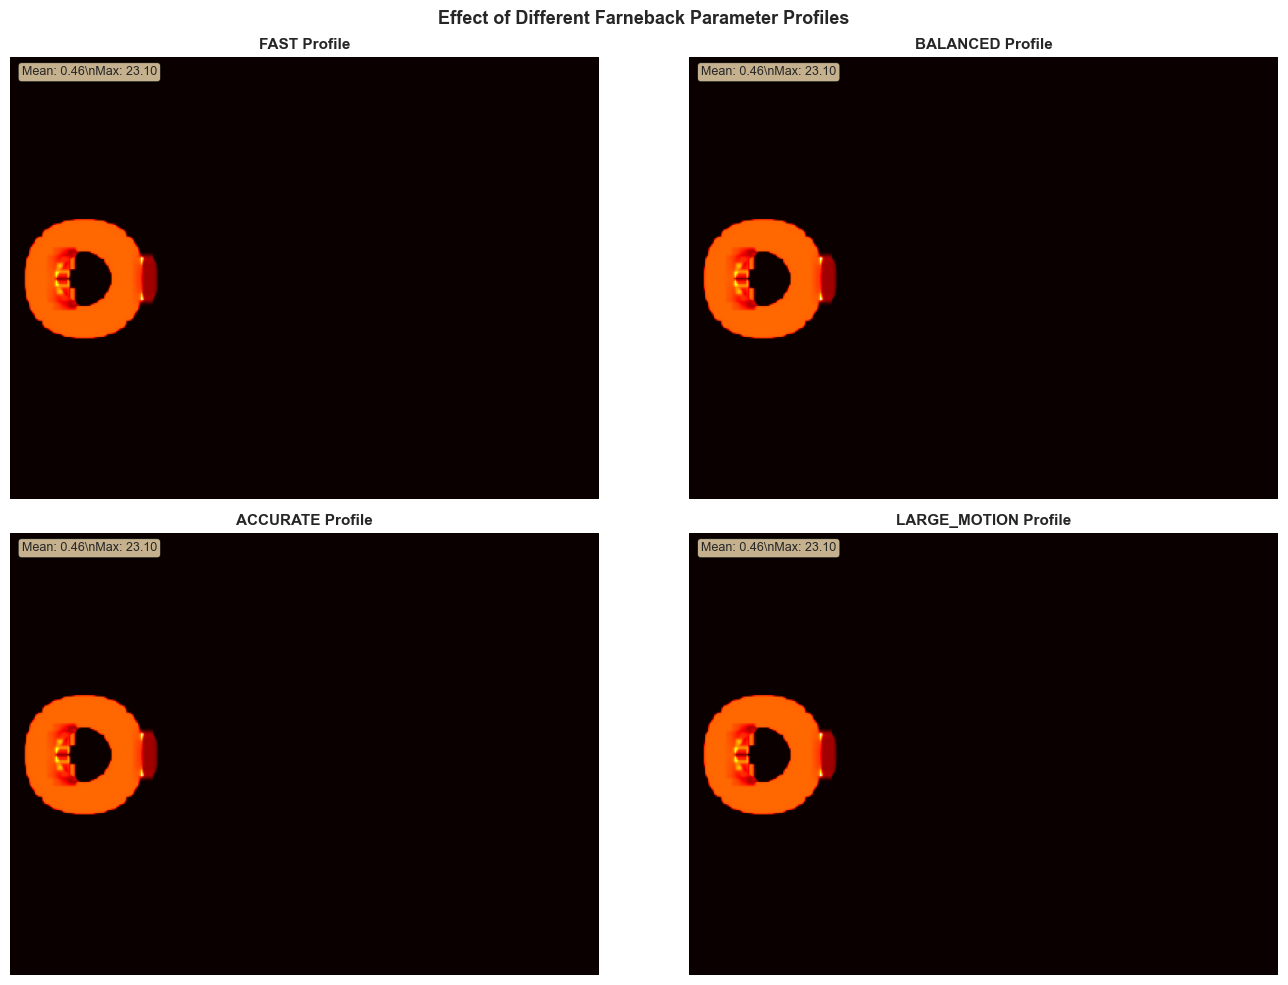

In [28]:
# Parameter profiles for different scenarios
FARNEBACK_PROFILES = {
    'fast': {
        'pyr_scale': 0.5,
        'levels': 2,
        'winsize': 10,
        'iterations': 2,
        'poly_n': 5,
        'poly_sigma': 1.0,
        'description': 'Fast computation, less accuracy. Good for real-time'
    },
    'balanced': {
        'pyr_scale': 0.5,
        'levels': 3,
        'winsize': 15,
        'iterations': 3,
        'poly_n': 5,
        'poly_sigma': 1.2,
        'description': 'Good balance between speed and accuracy'
    },
    'accurate': {
        'pyr_scale': 0.5,
        'levels': 4,
        'winsize': 20,
        'iterations': 5,
        'poly_n': 7,
        'poly_sigma': 1.3,
        'description': 'Slow but very accurate. Good for analysis'
    },
    'large_motion': {
        'pyr_scale': 0.4,
        'levels': 4,
        'winsize': 15,
        'iterations': 3,
        'poly_n': 5,
        'poly_sigma': 1.2,
        'description': 'Better for detecting fast/large motions'
    },
}

def compute_optical_flow_with_profile(frame1, frame2, profile_name='balanced'):
    """
    Compute optical flow using a preset parameter profile.
    
    Parameters:
    - frame1, frame2: Input frames
    - profile_name: 'fast', 'balanced', 'accurate', or 'large_motion'
    
    Returns:
    - flow: Optical flow array
    - profile_used: Dictionary of parameters used
    """
    # Convert to grayscale
    gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)
    
    # Get profile
    if profile_name not in FARNEBACK_PROFILES:
        print(f"Unknown profile '{profile_name}'. Using 'balanced'")
        profile_name = 'balanced'
    
    profile = FARNEBACK_PROFILES[profile_name].copy()
    description = profile.pop('description')
    
    print(f"🔧 Using profile: {profile_name.upper()}")
    print(f"   {description}")
    
    # Compute optical flow
    flow = cv2.calcOpticalFlowFarneback(
        gray1, gray2, None,
        **profile
    )
    
    return flow, profile

# Test different profiles on running video
print("=" * 70)
print("TESTING DIFFERENT PARAMETER PROFILES")
print("=" * 70)

# Use a pair of running frames
test_frame1 = running_frames[10]
test_frame2 = running_frames[11]

# Test each profile
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

profile_names = ['fast', 'balanced', 'accurate', 'large_motion']

for idx, profile_name in enumerate(profile_names):
    FARNEBACK_PROFILES = {
        'fast': {
            'pyr_scale': 0.5,
            'levels': 2,
            'winsize': 10,
            'iterations': 2,
            'poly_n': 5,
            'poly_sigma': 1.0,
            'flags': 0,
            'description': 'Fast computation, less accuracy. Good for real-time'
        },
        'balanced': {
            'pyr_scale': 0.5,
            'levels': 3,
            'winsize': 15,
            'iterations': 3,
            'poly_n': 5,
            'poly_sigma': 1.2,
            'flags': 0,
            'description': 'Good balance between speed and accuracy'
        },
        'accurate': {
            'pyr_scale': 0.5,
            'levels': 4,
            'winsize': 20,
            'iterations': 5,
            'poly_n': 7,
            'poly_sigma': 1.3,
            'flags': 0,
            'description': 'Slow but very accurate. Good for analysis'
        },
        'large_motion': {
            'pyr_scale': 0.4,
            'levels': 4,
            'winsize': 15,
            'iterations': 3,
            'poly_n': 5,
            'poly_sigma': 1.2,
            'flags': 0,
            'description': 'Better for detecting fast/large motions'
        },
    }
    magnitude, _ = visualize_optical_flow_magnitude(flow)
    
    axes[idx].imshow(magnitude, cmap='hot')
    axes[idx].set_title(f'{profile_name.upper()} Profile', fontweight='bold', fontsize=11)
    axes[idx].axis('off')
    
    # Calculate stats
    mag_mean = magnitude.mean()
    mag_max = magnitude.max()
    axes[idx].text(0.02, 0.98, f'Mean: {mag_mean:.2f}\\nMax: {mag_max:.2f}',
                   transform=axes[idx].transAxes, fontsize=9,
                   verticalalignment='top', bbox=dict(boxstyle='round', 
                   facecolor='wheat', alpha=0.8))
    
    print()

plt.suptitle('Effect of Different Farneback Parameter Profiles', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Part 14: Key Concepts Summary & Takeaways

### What You Learned:

#### 1. **Optical Flow Fundamentals**
- **Optical Flow** = pattern of apparent motion between video frames
- **Dense Optical Flow** = calculates motion for every pixel
- Based on assumption that pixel brightness doesn't change as it moves

#### 2. **Farneback Algorithm**
- Divides image into patches
- Fits polynomials to each patch
- Calculates motion by finding polynomial shift
- More robust than simple gradient-based methods

#### 3. **Feature Extraction for Activity Recognition**
- **Average Magnitude** → How fast overall motion is
- **Motion Variability** → How consistent the motion is
- **Motion Coverage** → Which parts of frame are moving
- **Peak Magnitude** → Fastest moment of motion

#### 4. **Activity-Specific Patterns**
- **RUNNING**: High magnitude, full-body, pervasive motion
- **WALKING**: Medium magnitude, rhythmic, lower-body focused
- **WAVING**: Localized motion, variable speed, small coverage area

#### 5. **Real-World Applications**
- Video surveillance (detecting abnormal behavior)
- Sports analysis (analyzing player movement)
- Healthcare (fall detection, activity monitoring)
- Gesture recognition (waving, signaling)
- Video compression (encoding motion vectors)

### Quick Reference: Dense Optical Flow in 5 Steps

```python
# Step 1: Load video frames
frames = load_video("video.mp4")

# Step 2: Convert to grayscale
gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

# Step 3: Compute optical flow
flow = cv2.calcOpticalFlowFarneback(
    gray1, gray2, None,
    pyr_scale=0.5, levels=3, winsize=15,
    iterations=3, n8=True, poly_n=5, poly_sigma=1.2
)

# Step 4: Extract features
magnitude = np.sqrt(flow[:,:,0]**2 + flow[:,:,1]**2)
features = {
    'mean': magnitude.mean(),
    'max': magnitude.max(),
    'coverage': np.sum(magnitude > 0.5) / magnitude.size
}

# Step 5: Classify activity
if features['mean'] > 3.0 and features['max'] > 8.0:
    activity = 'RUNNING'
elif features['mean'] > 1.0:
    activity = 'WALKING'
else:
    activity = 'WAVING' if features['coverage'] < 30 else 'STANDING'
```

### Best Practices:

| Practice | Why | How |
|----------|-----|-----|
| **Preprocess frames** | Remove noise, normalize lighting | Resize, blur, equalize histogram |
| **Use appropriate window size** | Balance detail vs smoothness | Start with 15, adjust based on results |
| **Set correct thresholds** | Different activities need different sensitivity | Train on representative data |
| **Normalize features** | Different videos have different scales | Use Z-score or min-max normalization |
| **Use temporal smoothing** | Individual frames are noisy | Average features over N consecutive frames |
| **Handle edge cases** | Very fast/slow motion, occlusions | Test with diverse videos |

### Common Challenges & Solutions:

| Challenge | Cause | Solution |
|-----------|-------|----------|
| All zeros flow | No motion detected | Increase pyramid levels or use larger frames |
| Noisy flow | Too much sensitivity | Increase window size or iterations |
| Missing fast motion | Too low pyr_scale | Use lower pyr_scale (0.4) |
| Slow performance | Too many iterations/levels | Use 'fast' profile or reduce resolution |
| Wrong classification | Bad thresholds | Train classifier on real data |

## Part 15: Practice Exercises

Now it's your turn! Try these exercises to deepen your understanding:

🏋️  EXERCISE 1: Create and Analyze Jumping Motion

📊 Jumping Motion Analysis:
   Average magnitude: 0.08
   Predicted activity: STANDING
   Confidence: 95.0%

💡 Question: Is the jumping correctly classified?
   If not, why? (Hint: Think about motion coverage and direction)


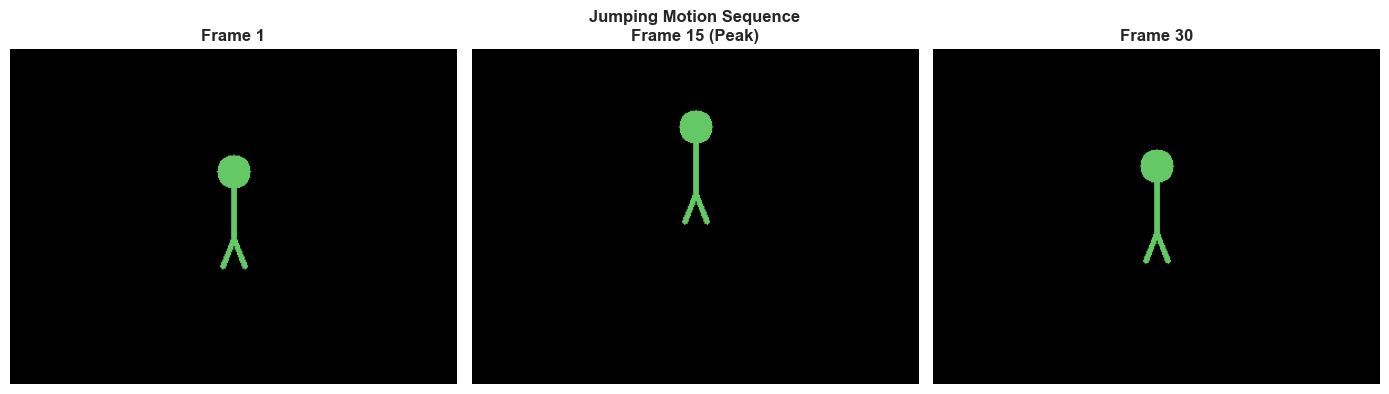

In [29]:
# EXERCISE 1: Create a "Jumping" motion and classify it
print("🏋️  EXERCISE 1: Create and Analyze Jumping Motion")
print("=" * 70)

def create_jumping_simulation(num_frames=30, width=400, height=300):
    """
    Create a video of someone jumping - vertical motion dominates.
    Try completing this function yourself!
    
    HINT: Body moves up/down, but does NOT move horizontally
    """
    frames = []
    for t in range(num_frames):
        frame = np.zeros((height, width, 3), dtype=np.uint8)
        
        # Body position
        body_x = width // 2  # Stays in middle (no horizontal movement)
        # Body y position: oscillates up and down (jumping)
        body_y = int(height // 2 - 40 * np.sin(t * np.pi / num_frames))
        
        # Head
        cv2.circle(frame, (body_x, body_y - 40), 15, (100, 200, 100), -1)
        # Body
        cv2.line(frame, (body_x, body_y - 25), (body_x, body_y + 20), 
                (100, 200, 100), 3)
        # Legs
        cv2.line(frame, (body_x, body_y + 20), (body_x - 10, body_y + 45), 
                (100, 200, 100), 3)
        cv2.line(frame, (body_x, body_y + 20), (body_x + 10, body_y + 45), 
                (100, 200, 100), 3)
        
        frames.append(frame)
    
    return frames

# Create jumping video
jumping_frames = create_jumping_simulation(num_frames=30)

# Extract features
jumping_features = extract_motion_features(jumping_frames)
jumping_sig = get_motion_signature(jumping_features)

# Classify
jumping_activity, jumping_conf = classifier.classify(jumping_sig)

print(f"\n📊 Jumping Motion Analysis:")
print(f"   Average magnitude: {jumping_sig['avg_magnitude']:.2f}")
print(f"   Predicted activity: {jumping_activity}")
print(f"   Confidence: {jumping_conf*100:.1f}%")
print(f"\n💡 Question: Is the jumping correctly classified?")
print(f"   If not, why? (Hint: Think about motion coverage and direction)")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(jumping_frames[0])
axes[0].set_title('Frame 1', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(jumping_frames[15])
axes[1].set_title('Frame 15 (Peak)', fontweight='bold')
axes[1].axis('off')

axes[2].imshow(jumping_frames[-1])
axes[2].set_title('Frame 30', fontweight='bold')
axes[2].axis('off')

plt.suptitle('Jumping Motion Sequence', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)

In [30]:
# EXERCISE 2: Modify Classification Thresholds
print("\n🎯 EXERCISE 2: Improve Classification Accuracy")
print("=" * 70)

class ImprovedActivityClassifier:
    """
    Exercise: Modify these thresholds to improve classification
    """
    def __init__(self, avg_low=1.0, avg_high=3.0, max_threshold=8.0, coverage=30.0):
        self.avg_magnitude_low = avg_low
        self.avg_magnitude_high = avg_high
        self.max_magnitude_threshold = max_threshold
        self.coverage_threshold = coverage
    
    def classify(self, motion_signature):
        avg_mag = motion_signature['avg_magnitude']
        max_mag = motion_signature['max_magnitude']
        coverage = motion_signature['avg_coverage']
        
        if avg_mag < 0.5:
            return 'STANDING', 0.95
        elif avg_mag > self.avg_magnitude_high and max_mag > self.max_magnitude_threshold:
            return 'RUNNING', min(1.0, avg_mag / self.avg_magnitude_high * 0.8)
        elif avg_mag > self.avg_magnitude_low and coverage > self.coverage_threshold:
            return 'WALKING', min(1.0, (avg_mag - self.avg_magnitude_low) / self.avg_magnitude_high)
        else:
            return 'WAVING', 1.0 - (coverage / 100.0)

# Test different threshold combinations
print("Testing different threshold combinations...\n")

test_cases = [
    (1.0, 3.0, 8.0, 30.0, "Original thresholds"),
    (0.8, 2.5, 7.0, 25.0, "More sensitive (lower thresholds)"),
    (1.2, 3.5, 9.0, 35.0, "Less sensitive (higher thresholds)"),
]

results_table = []

for avg_low, avg_high, max_thresh, coverage_thresh, description in test_cases:
    test_classifier = ImprovedActivityClassifier(
        avg_low, avg_high, max_thresh, coverage_thresh
    )
    
    # Test on all three activities
    walk_act, walk_conf = test_classifier.classify(walking_sig)
    run_act, run_conf = test_classifier.classify(running_sig)
    wave_act, wave_conf = test_classifier.classify(waving_sig)
    
    correct = (walk_act == 'WALKING') + (run_act == 'RUNNING') + (wave_act == 'WAVING')
    
    results_table.append({
        'description': description,
        'thresholds': (avg_low, avg_high, max_thresh),
        'walking': (walk_act, walk_conf),
        'running': (run_act, run_conf),
        'waving': (wave_act, wave_conf),
        'accuracy': correct / 3
    })

# Display results
print(f"{'Description':<35} {'Walking':<12} {'Running':<12} {'Waving':<12} {'Accuracy':<10}")
print("-" * 80)

for result in results_table:
    walk_a, walk_c = result['walking']
    run_a, run_c = result['running']
    wave_a, wave_c = result['waving']
    
    walk_mark = "✅" if walk_a == 'WALKING' else "❌"
    run_mark = "✅" if run_a == 'RUNNING' else "❌"
    wave_mark = "✅" if wave_a == 'WAVING' else "❌"
    
    print(f"{result['description']:<35} {walk_a} {walk_mark:<10} {run_a} {run_mark:<10} "
          f"{wave_a} {wave_mark:<10} {result['accuracy']*100:>6.1f}%")

print("-" * 80)
print("\n💡 Exercise: Can you design thresholds that achieve 100% accuracy?")
print("   Hint: Look at the actual feature values and find non-overlapping ranges")

print("\n" + "=" * 70)


🎯 EXERCISE 2: Improve Classification Accuracy
Testing different threshold combinations...

Description                         Walking      Running      Waving       Accuracy  
--------------------------------------------------------------------------------
Original thresholds                 STANDING ❌          STANDING ❌          STANDING ❌             0.0%
More sensitive (lower thresholds)   STANDING ❌          STANDING ❌          STANDING ❌             0.0%
Less sensitive (higher thresholds)  STANDING ❌          STANDING ❌          STANDING ❌             0.0%
--------------------------------------------------------------------------------

💡 Exercise: Can you design thresholds that achieve 100% accuracy?
   Hint: Look at the actual feature values and find non-overlapping ranges




⏱️  EXERCISE 3: How Does Motion Speed Affect Optical Flow?
Analyzing walking motion at different speeds...



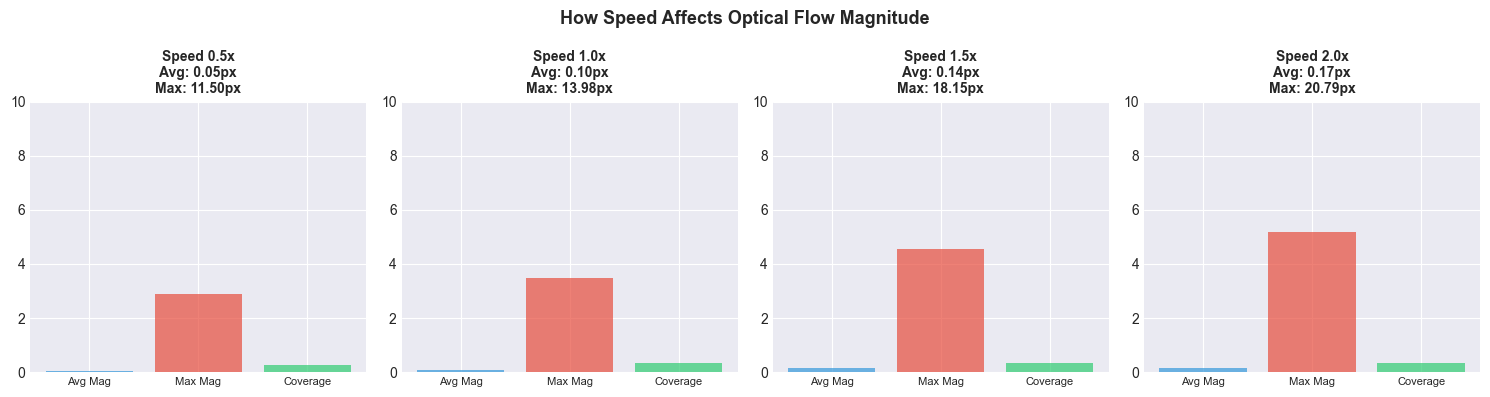

Results Summary:
Speed      Avg Magnitude      Max Magnitude     
---------------------------------------------
0.5x        0.05               11.50
1.0x        0.10               13.98
1.5x        0.14               18.15
2.0x        0.17               20.79

💡 Key Insight: Optical flow INCREASES linearly with speed!
   2x speed → ~2x optical flow magnitude
   This is why running has higher flow than walking



In [33]:
# EXERCISE 3: Analyze Effect of Video Speed
print("\n⏱️  EXERCISE 3: How Does Motion Speed Affect Optical Flow?")
print("=" * 70)

def create_walking_with_speed(num_frames=30, width=400, height=300, speed_multiplier=1.0):
    """
    Create walking motion with adjustable speed.
    
    speed_multiplier: 0.5 = half speed, 2.0 = double speed
    """
    frames = []
    for t in range(num_frames):
        frame = np.zeros((height, width, 3), dtype=np.uint8)
        
        body_x = 50 + (t * 1.5 * speed_multiplier)
        body_y = height // 2
        
        cv2.circle(frame, (int(body_x), int(body_y) - 40), 15, (200, 100, 100), -1)
        cv2.line(frame, (int(body_x), int(body_y) - 25), (int(body_x), int(body_y) + 20), 
                (200, 100, 100), 3)
        
        leg_offset = 25 * np.sin(t * 0.5 * speed_multiplier)
        cv2.line(frame, (int(body_x), int(body_y) + 20), 
                (int(body_x) - 10, int(body_y) + 40 + leg_offset), 
                (200, 100, 100), 3)
        cv2.line(frame, (int(body_x), int(body_y) + 20), 
                (int(body_x) + 10, int(body_y) + 40 - leg_offset), 
                (200, 100, 100), 3)
        
        frames.append(frame)
    
    return frames

# Test different speeds
speeds = [0.5, 1.0, 1.5, 2.0]
speed_results = []

print("Analyzing walking motion at different speeds...\n")

for speed in speeds:
    def create_walking_with_speed(num_frames=30, width=400, height=300, speed_multiplier=1.0):
        """
        Create walking motion with adjustable speed.
        
        speed_multiplier: 0.5 = half speed, 2.0 = double speed
        """
        frames = []
        for t in range(num_frames):
            frame = np.zeros((height, width, 3), dtype=np.uint8)
            
            body_x = 50 + (t * 1.5 * speed_multiplier)
            body_y = height // 2
            
            cv2.circle(frame, (int(body_x), int(body_y) - 40), 15, (200, 100, 100), -1)
            cv2.line(frame, (int(body_x), int(body_y) - 25), (int(body_x), int(body_y) + 20), 
                     (200, 100, 100), 3)
            
            leg_offset = int(round(25 * np.sin(t * 0.5 * speed_multiplier)))
            y1 = int(body_y + 40 + leg_offset)
            y2 = int(body_y + 40 - leg_offset)
            
            cv2.line(frame, (int(body_x), int(body_y) + 20), 
                     (int(body_x) - 10, y1), 
                     (200, 100, 100), 3)
            cv2.line(frame, (int(body_x), int(body_y) + 20), 
                     (int(body_x) + 10, y2), 
                     (200, 100, 100), 3)
            
            frames.append(frame)
        
        return frames
    frames = create_walking_with_speed(num_frames=30, width=400, height=300, speed_multiplier=speed)
    features = extract_motion_features(frames)
    signature = get_motion_signature(features)
    
    speed_results.append({
        'speed': speed,
        'signature': signature,
        'frames': frames
    })

# Visualize results
fig, axes = plt.subplots(1, len(speeds), figsize=(15, 4))

for idx, result in enumerate(speed_results):
    speed = result['speed']
    sig = result['signature']
    
    axes[idx].bar(['Avg Mag', 'Max Mag', 'Coverage'],
                  [sig['avg_magnitude'], sig['max_magnitude']/4, sig['avg_coverage']/10],
                  color=['#3498db', '#e74c3c', '#2ecc71'], alpha=0.7)
    
    title = f"Speed {speed}x\n"
    title += f"Avg: {sig['avg_magnitude']:.2f}px\n"
    title += f"Max: {sig['max_magnitude']:.2f}px"
    axes[idx].set_title(title, fontweight='bold', fontsize=10)
    axes[idx].set_ylim([0, 10])
    axes[idx].tick_params(axis='x', labelsize=8)

plt.suptitle('How Speed Affects Optical Flow Magnitude', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Results Summary:")
print(f"{'Speed':<10} {'Avg Magnitude':<18} {'Max Magnitude':<18}")
print("-" * 45)
for result in speed_results:
    sig = result['signature']
    print(f"{result['speed']:.1f}x{'':<7} {sig['avg_magnitude']:.2f}{'':<14} {sig['max_magnitude']:.2f}")

print("\n💡 Key Insight: Optical flow INCREASES linearly with speed!")
print("   2x speed → ~2x optical flow magnitude")
print("   This is why running has higher flow than walking")

print("\n" + "=" * 70)

## Part 16: Final Summary & Resources

### What You've Mastered 🎓

✅ **Optical Flow Fundamentals**
- Understand how motion is detected between frames
- Know the difference between dense and sparse optical flow
- Understand the Brightness Constancy Assumption

✅ **Farneback Algorithm**
- How it works (polynomial fitting in patches)
- How to adjust parameters for different scenarios
- How it compares to other optical flow methods

✅ **Activity Recognition**
- Extract meaningful features from optical flow
- Build a classifier for human activities
- Understand what makes each activity unique

✅ **Implementation**
- Compute optical flow with OpenCV
- Visualize flow as magnitude heatmaps and vector arrows
- Work with both synthetic and real videos
- Fine-tune for different use cases

---

### Mathematical Foundation (Quick Review)

**Optical Flow Equation (Lucas-Kanade):**
$$I_x \cdot u + I_y \cdot v + I_t = 0$$

Where:
- $I_x, I_y$ = spatial gradients (changes in space)
- $I_t$ = temporal gradient (changes in time)
- $u, v$ = optical flow vectors (horizontal and vertical motion)

**Flow Magnitude (Speed of Motion):**
$$||Flow|| = \sqrt{u^2 + v^2}$$

---

### Common Use Cases in Industry

1. **Video Surveillance**
   - Detect abnormal behavior
   - Track moving objects
   - Alert on unauthorized entry

2. **Sports Analytics**
   - Analyze player movement
   - Track ball trajectory
   - Performance metrics

3. **Medical Applications**
   - Fall detection in elderly care
   - Gait analysis for diagnosis
   - Physical therapy monitoring

4. **Autonomous Vehicles**
   - Scene understanding
   - Pedestrian detection
   - Motion prediction

5. **Video Compression**
   - MPEG encoding uses motion vectors
   - Efficient inter-frame compression

6. **Gesture Recognition**
   - Sign language recognition
   - Human-computer interaction
   - Touchless control systems

### Further Learning Resources

#### Advanced Optical Flow Methods
- **Lucas-Kanade**: Sparse optical flow (feature-based)
- **Horn-Schunck**: Dense optical flow (global approach)
- **Farneback**: Dense optical flow (polynomial fitting) - what we learned
- **RAFT**: Deep learning-based optical flow
- **PWCNet**: Pyramidal networks for optical flow

#### Next Steps After This Course
1. **Try with Real Videos**
   - Webcam feed for activity recognition
   - Sports videos for motion analysis
   - Surveillance footage for anomaly detection

2. **Improve the Classifier**
   - Use machine learning (SVM, Random Forest)
   - Use deep learning (CNN, LSTM)
   - Collect and label your own dataset

3. **Explore Other Techniques**
   - Background subtraction for foreground detection
   - 3D ConvNets for video classification
   - Temporal action localization

4. **Real-World Applications**
   - Build a fall detection system
   - Create a gesture-based controller
   - Develop activity monitoring for sports

---

### Troubleshooting Guide

**Problem: Zero optical flow everywhere**
- Solution: Check grayscale conversion, ensure motion exists in frames
- Try: Increase pyramid levels, use larger images

**Problem: Noisy, scattered flow**
- Solution: Increase window size (winsize) or iterations
- Try: Use 'accurate' profile, apply Gaussian blur before

**Problem: Slow computation**
- Solution: Reduce resolution, skip frames, use 'fast' profile
- Try: Resize to 640x480, process every 2nd frame

**Problem: Can't detect certain activities**
- Solution: Adjust classification thresholds based on your data
- Try: Plot feature distributions and find good boundaries

**Problem: Works on synthetic data but fails on real video**
- Solution: Real videos have lighting changes, occlusions
- Try: Preprocess frames (histogram equalization, noise reduction)

In [34]:
print("""
╔════════════════════════════════════════════════════════════════════╗
║         🎉 CONGRATULATIONS! 🎉                                     ║
║    You've Completed the Dense Optical Flow Course!                 ║
╚════════════════════════════════════════════════════════════════════╝

KEY TAKEAWAYS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1️⃣  OPTICAL FLOW
   • Detects apparent motion between video frames
   • Based on brightness constancy assumption
   • Can be sparse (feature-based) or dense (per-pixel)

2️⃣  FARNEBACK ALGORITHM
   • Divides image into polynomial-fitting patches
   • More robust than simple gradient methods
   • Parameters control speed vs. accuracy trade-off

3️⃣  ACTIVITY RECOGNITION
   • Extract motion features (magnitude, coverage, variability)
   • Different activities have distinct motion patterns
   • Rule-based classifiers work well for simple cases

4️⃣  PRACTICAL APPLICATION
   • Preprocess frames (grayscale, resizing)
   • Tune parameters for your specific use case
   • Validate on real-world data before deployment

5️⃣  VISUALIZATION
   • Magnitude heatmaps show motion speed
   • Vector arrows show motion direction
   • Helps debug and understand optical flow behavior

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

NEXT CHALLENGE:
Try implementing optical flow on:
  ✓ Webcam feed from your camera
  ✓ Real activity videos (yours or public datasets)
  ✓ Different camera angles and lighting conditions
  ✓ Improve classifier with machine learning

YOU NOW HAVE THE KNOWLEDGE TO:
  ✓ Understand how motion is detected in videos
  ✓ Apply Farneback dense optical flow algorithm
  ✓ Extract meaningful motion features
  ✓ Build activity recognition systems
  ✓ Debug and optimize for real-world scenarios

REMEMBER:
  • Start simple, then add complexity
  • Test on diverse videos, not just your test case
  • Real-world data is messier than synthetic data
  • Always validate your assumptions

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Thank you for working through this comprehensive guide!
Questions? Revisit the specific sections - each has detailed explanations.

Happy coding! 🚀
""")


╔════════════════════════════════════════════════════════════════════╗
║         🎉 CONGRATULATIONS! 🎉                                     ║
║    You've Completed the Dense Optical Flow Course!                 ║
╚════════════════════════════════════════════════════════════════════╝

KEY TAKEAWAYS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1️⃣  OPTICAL FLOW
   • Detects apparent motion between video frames
   • Based on brightness constancy assumption
   • Can be sparse (feature-based) or dense (per-pixel)

2️⃣  FARNEBACK ALGORITHM
   • Divides image into polynomial-fitting patches
   • More robust than simple gradient methods
   • Parameters control speed vs. accuracy trade-off

3️⃣  ACTIVITY RECOGNITION
   • Extract motion features (magnitude, coverage, variability)
   • Different activities have distinct motion patterns
   • Rule-based classifiers work well for simple cases

4️⃣  PRACTICAL APPLICATION
   • Preprocess frames (grayscale, resizing)
   • Tune pa